<a href="https://colab.research.google.com/github/KishoreSebastian/netflix-eda-project/blob/main/Project1_Netflix_movies_and_tv_shows_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

df = pd.read_csv('/content/netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

In [29]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Remove irrelevant columns
df_clean = df.drop(['show_id'], axis=1)

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8807 non-null   object        
 1   title         8807 non-null   object        
 2   director      8807 non-null   object        
 3   cast          8807 non-null   object        
 4   country       8807 non-null   object        
 5   date_added    8709 non-null   datetime64[ns]
 6   release_year  8807 non-null   int64         
 7   rating        8803 non-null   object        
 8   duration      8804 non-null   object        
 9   listed_in     8807 non-null   object        
 10  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 757.0+ KB


In [30]:
df_clean['type'].value_counts()


,count
type,
Movie,6131
TV Show,2676


In [31]:
df_clean['country'].value_counts().head(10)


,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [32]:
df_clean['listed_in'].value_counts().head(10)


,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [33]:
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['year_added'].value_counts().sort_index()


,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


In [34]:
df_clean['rating'].value_counts()


,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


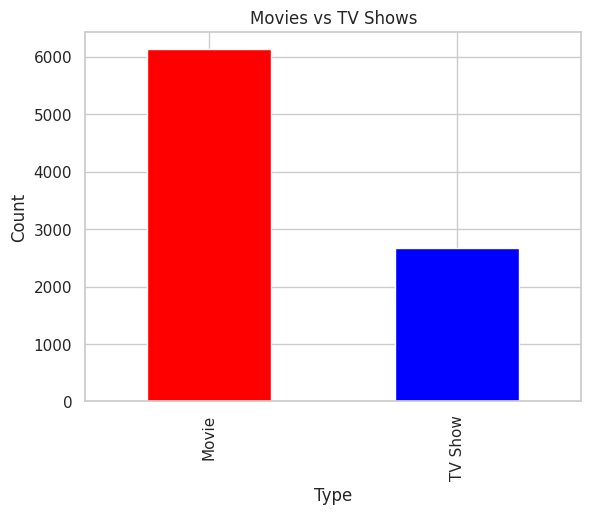

In [35]:
df_clean['type'].value_counts().plot(kind='bar', color=['red','blue'])
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


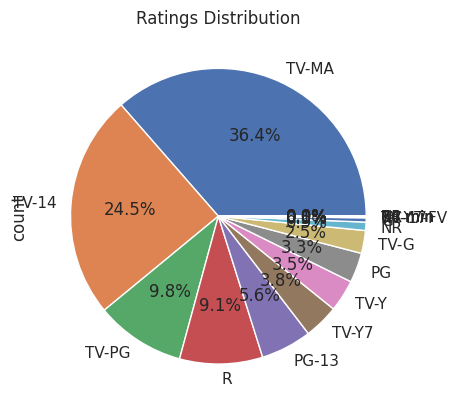

In [36]:
df_clean['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Ratings Distribution')
plt.show()


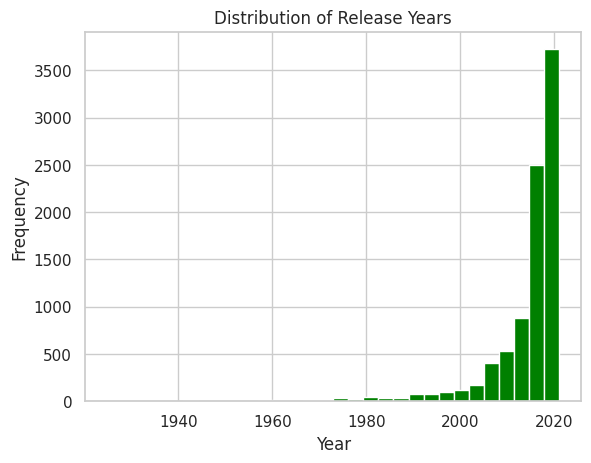

In [37]:
plt.hist(df_clean['release_year'], bins=30, color='green')
plt.title('Distribution of Release Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()


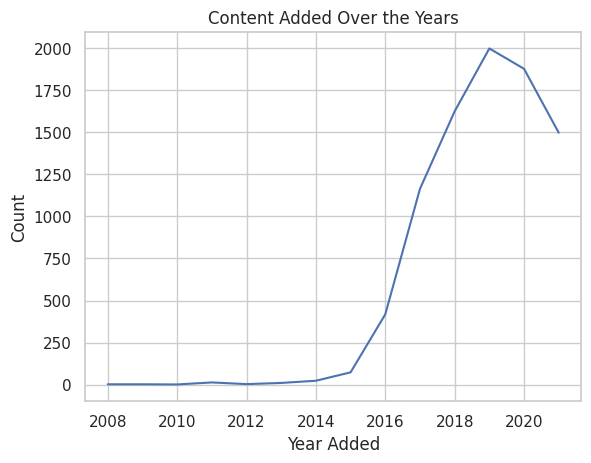

In [38]:
df_clean['year_added'].value_counts().sort_index().plot(kind='line')
plt.title('Content Added Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.show()


In [39]:
# Filter only movies
movies = df_clean[df_clean['type'] == 'Movie'].copy()

# Remove " min" text safely
movies['duration'] = movies['duration'].astype(str).str.replace(' min', '', regex=False)

# Convert to numeric (invalid values become NaN)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Drop rows where duration is missing
movies = movies.dropna(subset=['duration'])


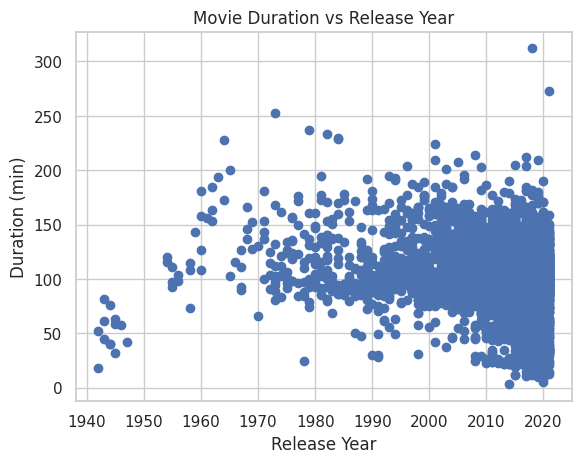

In [40]:
plt.scatter(movies['release_year'], movies['duration'])
plt.title('Movie Duration vs Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (min)')
plt.show()


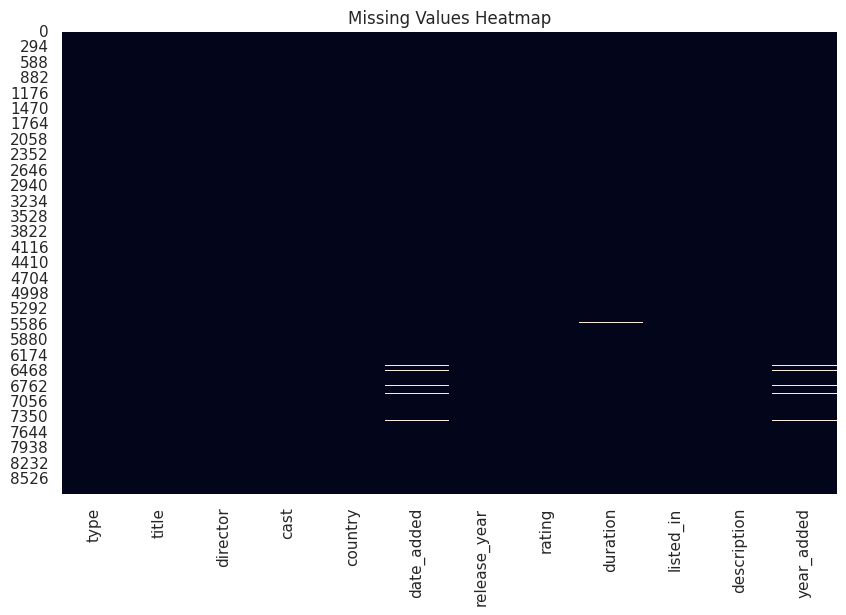

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()


### Insights


*  Based on the Movies vs TV Shows bar chart, Netflix has more movies than TV shows, showing a movie‑heavy content strategy.
* The Top Countries bar chart shows that the USA and India produce the most Netflix titles, indicating strong content partnerships.  
*   From the Genre frequency chart, Drama and International Movies are the most common genres, showing global audience interest.
*  The Content Added Per Year line chart reveals a sharp increase in titles added after 2015, matching Netflix’s global expansion.
*   The Ratings pie chart shows that TV‑MA and TV‑14 dominate, indicating Netflix’s focus on mature audiences.

### Most Surprising Finding  
The most surprising finding was the sharp rise in content added after 2015, clearly visible in the line chart. This shows how quickly Netflix expanded globally within a short period. It also highlights Netflix’s shift from being a streaming service to becoming a major content producer.





